In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
param_combos = []
with open("parameter_sweep.txt", "r") as f:
    current_combo = {}
    for line in f:
        line = line.strip()
        if line == "":
            if current_combo:
                param_combos.append(current_combo)
                current_combo = {}
        else:
            key, value = line.split("=", 1)
            current_combo[key] = value
    if current_combo:
        param_combos.append(current_combo)

In [3]:
import os
all_figure_names = os.listdir("param_sweep_figures")
all_figure_names.sort()


In [4]:
def get_figures_for_combo(idx):
    # Filter out filenames that begin with the number
    figure_names = [name for name in all_figure_names if name.startswith(str(idx) + "_")]
    figure_names.sort()
    return figure_names

def get_vals_from_filename(filename):
    split = filename.split("_")
    q = float(split[1][1:])
    iteration = int(split[2].split(".")[0])
    return q, iteration

def pretty_print_dict(d):
    for key, value in d.items():
        print(f"{key}: {value}")

In [5]:
def plot_combo(idx):
    combo = param_combos[idx]
    figures = get_figures_for_combo(idx)
    qvals = []
    itervals = []
    for fig in figures:
        q, iteration = get_vals_from_filename(fig)
        if q not in qvals:
            qvals.append(q)
        if iteration not in itervals:
            itervals.append(iteration)
    
    width = len(qvals)
    height = len(itervals)
    
    subsampling = 1
    sample_img = plt.imread("param_sweep_figures/" + figures[0])
    img_h, img_w, channels = sample_img.shape
    img_h //= subsampling
    img_w //= subsampling

    
    grid_canvas = np.zeros((height * img_h, width * img_w, channels), dtype=sample_img.dtype)
    
    pretty_print_dict(combo)
    
    for fig in figures:
        q, iteration = get_vals_from_filename(fig)
        q_idx = qvals.index(q)
        iter_idx = itervals.index(iteration)
        img = plt.imread("param_sweep_figures/" + fig)
        img = img[::subsampling, ::subsampling]
        y_start = iter_idx * img_h
        x_start = q_idx * img_w
        grid_canvas[y_start : y_start + img_h, x_start : x_start + img_w] = img
    
    fig, ax = plt.subplots(figsize=(width * 5, height * 5))
    ax.imshow(grid_canvas)
    ax.set_xticks([(i + 0.5) * img_w for i in range(width)], labels=[str(q) for q in qvals])
    ax.set_yticks([(i + 0.5) * img_h for i in range(height)], labels=[str(iter) for iter in itervals])
    ax.set_xlabel("q value")
    ax.set_ylabel("Iteration")
    ax.set_title(f"Combination {idx}")
    plt.show()

loss: 3.8409467825873964
dev: 2.0974131367116424
combination_idx: 0
use_residuals: 1
layers: [128, 128]
learning_rate: 0.001


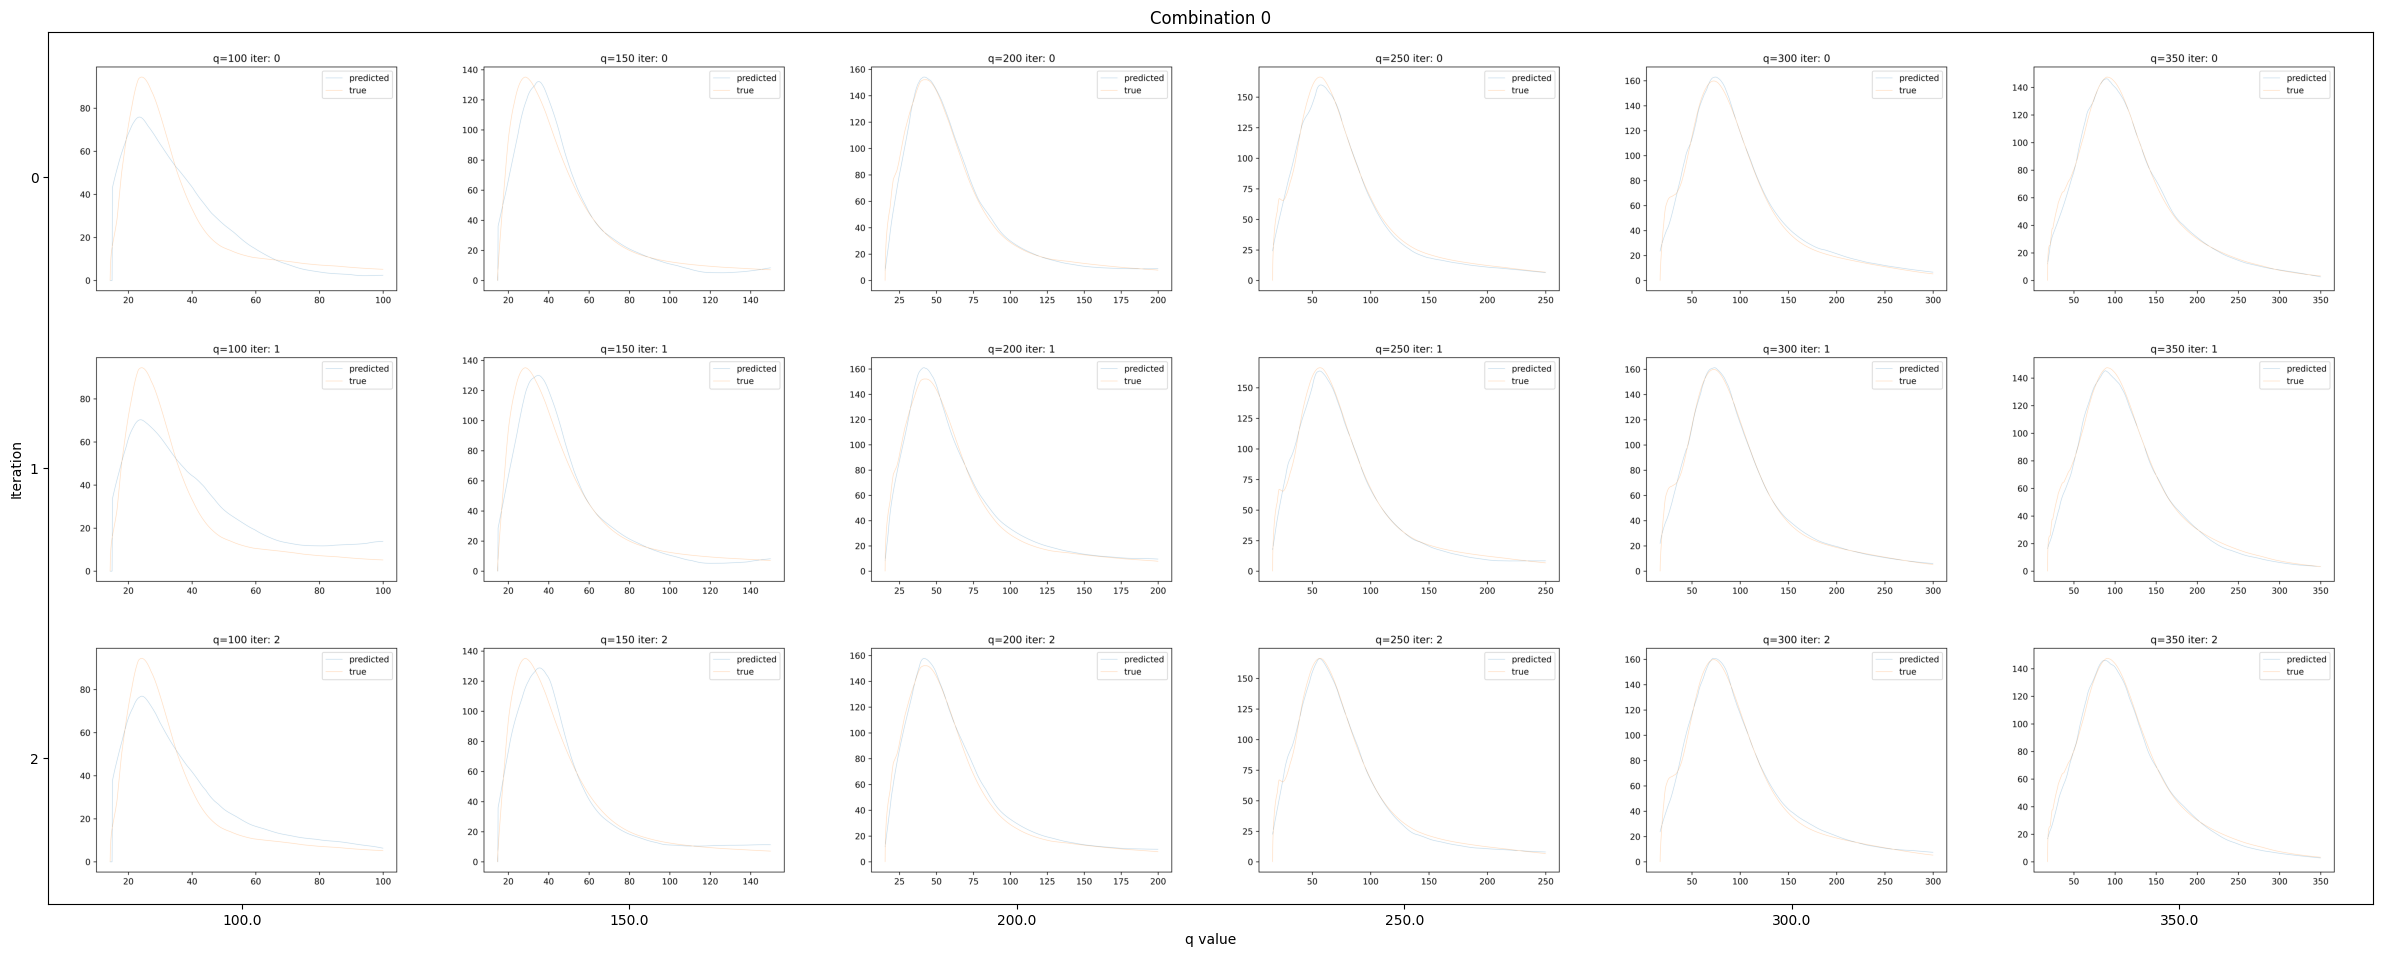

In [6]:
plot_combo(0)